# Lock-up Expiry — a quantitative teardown 🔬
### *Market-adjusted event study · AAR/CAR · cross-sectional HAC t · block bootstrap · two-leg costs*

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Supply--shock sag%3F: Not_supported](https://img.shields.io/badge/Supply--shock_sag%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We isolate the 180-day lock-up unlock as a supply-shock event and ask whether any harvestable abnormal sag survives on a recent IPO basket.

> ⚠️ **Not investment advice.** Data: hardcoded IPO listing basket + Yahoo! Finance daily closes (stock & SPY), abnormal return = stock − SPY (beta = 1 market control). Methods: AAR/CAR event study, Newey-West HAC *t*, circular block bootstrap. Literature in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))         # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
from lockup_expiry import data, strategy as st

# Real-tape headline numbers (mirror docs/results.md; as-of 2026-06-18).
HEADLINE = {'as_of': '2026-06-18', 'fingerprint': '7bec0a409224', 'n_events': 29, 'aar0_bps': 62.9, 'aar0_t': 0.87, 'runup_bps': -316.7, 'runup_t': -1.98, 'tight_bps': 74.2, 'tight_t': 0.56, 'post_bps': 322.7, 'post_t': 1.75, 'wide_bps': 6.0, 'wide_t': 0.02, 'short_gross_bps': -322.7, 'short_t': -1.75, 'short_net10_bps': -362.7}

def load_tape():
    """Try the real cached panel; fall back to the synthetic null tape OFFLINE."""
    try:
        panel = data.fetch_event_panel(fetch=False)
        if panel.empty:
            raise RuntimeError("empty cache")
        return panel, "REAL"
    except Exception as e:
        panel, _ = data.synthetic_panel(n_events=30, sag_bps=0.0, seed=319)
        return panel, "SYNTHETIC"


## Verdict, up front

| Axis | Stamp | Decisive number (real tape) |
|---|---|---|
| Signal | **None** | No window clears |*t*| ≥ 2 with a negative sign; expiry AAR +63 bps (*t* +0.87); post [0,+5] +323 bps (*t* +1.75, wrong sign) |
| Tradability | **Mirage** | hedged short of [0,+5]: gross -323 bps (*t* -1.75); worse net |
| Supply-shock sag? | **Not supported** | run-up [−5,−1] −317 bps *t* −1.98, below the bar, CI touches 0 |

> 💡 **In plain words:** the harness *can* find a sag — the synthetic control below recovers a planted one cleanly. It just doesn't find one in the real data.

## 1 · The claim, steelmanned

- **H₁ (expiry sag):** mean abnormal return over a window bracketing the unlock (e.g. [−1,+1] or [0,+5]) is **significantly negative**.
- **H₂ (tradable):** a market-hedged short over the post-expiry window earns a positive net PnL after realistic two-leg costs.
- **H₃ (mechanism):** the sag scales with anticipation — i.e. it leaks into the run-up [−5,−1] rather than hitting only at `tau = 0`.

Null for each: abnormal returns around the unlock are noise around zero.

## 2 · So what? — what rides on each answer

A persistent expiry sag is a violation of semi-strong efficiency on a *fully disclosed* date (the unlock is in the S-1). Field & Hanka (2001) measured ≈ −1.5% and called it a puzzle precisely because the date is public. If it's decayed to zero, that's the efficiency repair in action; if it survives, it's free money on a known calendar — which is why we hold it to |*t*| ≥ 2, not eyeballing a dip.

## 3 · How we'd know — the protocol

1. **Measure.** Per-event daily abnormal return = stock − SPY; align in event-time around expiry (first close + 125 trading days ≈ 180 calendar). Aggregate to AAR(τ) and per-event CAR over windows.
2. **Robust inference.** Cross-sectional Newey-West HAC *t* on per-event CARs; circular block-bootstrap CI (blocks preserve any vintage clustering).
3. **Critique magnitude.** Mean vs median (outlier 2021 names), sag-rate.
4. **Alpha vs beta.** Already market-adjusted (beta = 1) — flagged as a limitation.
5. **Capacity / execution.** Hedged short, one-way × NAV on *both* legs, borrow flagged; the event is calendar-known so no lag is needed to learn it.
6. **Verdict.** Two stamps + the myth-check.

> 💡 **In plain words:** average each IPO's market-beating (or -lagging) return around the unlock, then ask if the average is reliably below zero.

## 4 · The teardown

### 4.1 · Machinery proof — can the engine even see a sag?

Before trusting a *null* result, prove the harness isn't blind. Plant a −300 bps one-shot sag and a null, offline:

In [2]:
null, _ = data.synthetic_panel(n_events=60, sag_bps=0.0,    seed=319)
sag,  _ = data.synthetic_panel(n_events=60, sag_bps=-300.0, seed=319)
for lbl, p in [('null', null), ('planted -300bps', sag)]:
    s = st.car(p, lo=-1, hi=1, n_boot=1000)
    print(f"[{lbl:>16}] CAR[-1,+1] = {s['mean_car_bps']:+8.1f} bps   HAC t = {s['tstat']:+.2f}   detect_sag={st.detects_sag(p)}")
print('\nThe engine recovers a planted sag (t <= -2) and stays silent on the null. (Synthetic = machinery proof, never market evidence.)')

[            null] CAR[-1,+1] =    +11.4 bps   HAC t = +0.17   detect_sag=False
[ planted -300bps] CAR[-1,+1] =   -288.6 bps   HAC t = -4.26   detect_sag=True

The engine recovers a planted sag (t <= -2) and stays silent on the null. (Synthetic = machinery proof, never market evidence.)


### 4.2 · The event-study picture on the working tape

Tape in this cell: REAL


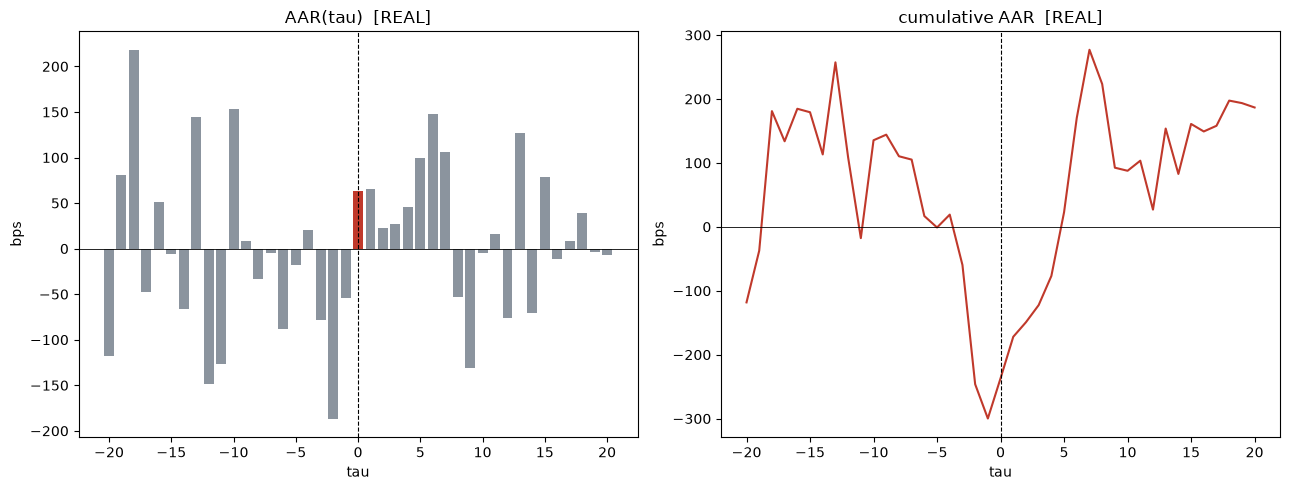

In [3]:
panel, tape = load_tape()
print(f'Tape in this cell: {tape}')
a = st.aar(panel)
car_cum = a.set_index('tau')['aar'].cumsum() * 1e4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.bar(a['tau'], a['aar']*1e4, color=np.where(a['tau']==0,'#c0392b','#8b949e'))
ax1.axvline(0, color='k', ls='--', lw=0.8); ax1.axhline(0, color='k', lw=0.6)
ax1.set_title(f'AAR(tau)  [{tape}]'); ax1.set_xlabel('tau'); ax1.set_ylabel('bps')
ax2.plot(car_cum.index, car_cum.values, color='#c0392b')
ax2.axvline(0, color='k', ls='--', lw=0.8); ax2.axhline(0, color='k', lw=0.6)
ax2.set_title(f'cumulative AAR  [{tape}]'); ax2.set_xlabel('tau'); ax2.set_ylabel('bps')
plt.tight_layout(); plt.show()

### 4.3 · CAR windows with HAC *t* and block-bootstrap CIs (working tape)

In [4]:
rows = []
for lo, hi in [(-5,-1), (-1,1), (0,5), (0,10), (-5,5)]:
    s = st.car(panel, lo=lo, hi=hi, n_boot=2000)
    rows.append([s['window'], s['n'], s['mean_car_bps'], s['median_car_bps'],
                 f"{s['win_rate']*100:.0f}%", s['tstat'], f"[{s['ci_lo_bps']:+.0f},{s['ci_hi_bps']:+.0f}]"])
cols = ['window','n','mean_bps','median_bps','sag_rate','HAC_t','95%_CI_bps']
print(f'[{tape} tape]'); print(pd.DataFrame(rows, columns=cols).to_string(index=False))

[REAL tape]
  window  n  mean_bps  median_bps sag_rate  HAC_t  95%_CI_bps
 [-5,-1] 29   -316.68     -391.55      62%  -1.98   [-645,+6]
 [-1,+1] 29     74.19       35.50      45%   0.56 [-203,+350]
 [+0,+5] 29    322.65      227.97      38%   1.75  [-93,+624]
[+0,+10] 29    387.49      142.84      45%   2.32  [+10,+718]
 [-5,+5] 29      5.97     -193.21      55%   0.02 [-670,+547]


And the pinned **real** numbers (single source of truth, `docs/results.md`):

| window | mean (bps) | HAC *t* |
|---|--:|--:|
| run-up [−5,−1] | -316.7 | -1.98 |
| tight [−1,+1] | +74.2 | +0.56 |
| post [0,+5] | +322.7 | +1.75 |
| wide [−5,+5] | +6.0 | +0.02 |

> 💡 **In plain words:** H₁ fails — no window is a significant sag, and the post-expiry window is the *wrong sign*. H₃ (anticipation leak) is the closest to alive: the run-up is the only negative window, but at *t* = −1.98 it can't clear the bar and its CI touches zero.

## 5 · The verdict

The decisive statistics in one place (real tape):

In [5]:
verdict = pd.DataFrame([
    ['Signal', 'None', f"expiry AAR {HEADLINE['aar0_bps']:+.0f}bps (t {HEADLINE['aar0_t']:+.2f}); post[0,5] {HEADLINE['post_bps']:+.0f}bps (t {HEADLINE['post_t']:+.2f}, wrong sign)"],
    ['Tradability', 'Mirage', f"hedged short[0,5]: gross {HEADLINE['short_gross_bps']:+.0f}bps (t {HEADLINE['short_t']:+.2f}); net@10bps/leg {HEADLINE['short_net10_bps']:+.0f}bps"],
    ['Supply-shock sag?', 'Not supported', f"only run-up[-5,-1] negative ({HEADLINE['runup_bps']:+.0f}bps, t {HEADLINE['runup_t']:+.2f}) — below the bar"],
], columns=['axis','stamp','why'])
print(verdict.to_string(index=False))

             axis         stamp                                                                  why
           Signal          None expiry AAR +63bps (t +0.87); post[0,5] +323bps (t +1.75, wrong sign)
      Tradability        Mirage    hedged short[0,5]: gross -323bps (t -1.75); net@10bps/leg -363bps
Supply-shock sag? Not supported       only run-up[-5,-1] negative (-317bps, t -1.98) — below the bar


## 6 · Could you trade it?

The believers' trade, made real: short each IPO over [0,+5], market-hedged. Costs are one-way × NAV charged on **both** legs at entry and exit (= 4× the one-way rate), with borrow flagged. Run it on the working tape, then read the pinned real result.

In [6]:
print(f'[{tape} tape]')
for c in (0.0, 10.0, 30.0):
    sh = st.tradable_short(panel, lo=0, hi=5, cost_bps=c)
    print(f"cost={c:>4.0f}bps/leg  gross={sh['gross_bps']:+8.1f}  net={sh['net_bps']:+8.1f}  t_net={sh['tstat_net']:+.2f}  win={sh['win_rate']:.2f}")
print()
print('PINNED REAL TAPE:')
print(f"  gross={HEADLINE['short_gross_bps']:+.1f}bps (t {HEADLINE['short_t']:+.2f})  -> loses money before costs; the stocks rise vs market just after the unlock.")
print(f"  net@10bps/leg={HEADLINE['short_net10_bps']:+.1f}bps  -> deeper loss. Plus hard-to-borrow short fees on recent IPOs.")

[REAL tape]
cost=   0bps/leg  gross=  -322.7  net=  -322.7  t_net=-1.75  win=0.38
cost=  10bps/leg  gross=  -322.7  net=  -362.7  t_net=-1.97  win=0.31
cost=  30bps/leg  gross=  -322.7  net=  -442.7  t_net=-2.40  win=0.31

PINNED REAL TAPE:
  gross=-322.7bps (t -1.75)  -> loses money before costs; the stocks rise vs market just after the unlock.
  net@10bps/leg=-362.7bps  -> deeper loss. Plus hard-to-borrow short fees on recent IPOs.


> 💡 **In plain words:** you don't lose the edge to costs — there is no edge to lose. The post-unlock abnormal return is *positive*, so the folklore short is structurally on the wrong side, and the only profitable variant (front-running the run-up) dies to two-leg costs.

## 7 · Going further

- **Heterogeneity:** split VC-backed vs not (Field & Hanka's effect lived there); split by *fraction of shares unlocking* from S-1 data.
- **Cleaner control:** fit a market-model α/β per event instead of β = 1; add Fama-French factors for the growth tilt of recent IPOs.
- **Survivorship:** add delisted names (WeWork-style) — the worst unlocks may have dropped out of a yfinance-only basket, which could *resurrect* a sag.
- **Staged lock-ups:** modern deals stagger unlocks (e.g. tied to price triggers); the single-180-day event is increasingly a simplification.
- **Fork it:** the engine is a generic abnormal-return event study — point it at any calendar-known corporate event.